In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV


In [259]:
data=pd.read_csv("/kaggle/input/bike-sharing-dataset/day.csv")
data2=pd.read_csv("/kaggle/input/bike-sharing-dataset/hour.csv")

**WEEK 1**

In [260]:
data.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [261]:
data2.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [262]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [263]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [264]:
data['dteday'] = pd.to_datetime(data['dteday'])


In [265]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [266]:
data2['dteday'] = pd.to_datetime(data2['dteday'])


In [267]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [268]:
data.shape

(731, 16)

In [269]:
data2.shape

(17379, 17)

In [270]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
726    False
727    False
728    False
729    False
730    False
Length: 731, dtype: bool

In [271]:
data.duplicated().sum()

0

In [272]:
data2.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17374    False
17375    False
17376    False
17377    False
17378    False
Length: 17379, dtype: bool

In [273]:
data2.duplicated().sum()

0

In [274]:
data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [275]:
data2.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [276]:
data.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [277]:
data2.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045824,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


**WEEK 2********

In [278]:
data.shape

(731, 16)

In [279]:
data.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)


In [280]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   holiday     731 non-null    int64  
 3   weekday     731 non-null    int64  
 4   workingday  731 non-null    int64  
 5   weathersit  731 non-null    int64  
 6   temp        731 non-null    float64
 7   atemp       731 non-null    float64
 8   hum         731 non-null    float64
 9   windspeed   731 non-null    float64
 10  cnt         731 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB


In [281]:
data2.shape

(17379, 17)

In [282]:
data2.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)


In [283]:
data2.shape

(17379, 12)

In [284]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   mnth        17379 non-null  int64  
 2   hr          17379 non-null  int64  
 3   holiday     17379 non-null  int64  
 4   weekday     17379 non-null  int64  
 5   workingday  17379 non-null  int64  
 6   weathersit  17379 non-null  int64  
 7   temp        17379 non-null  float64
 8   atemp       17379 non-null  float64
 9   hum         17379 non-null  float64
 10  windspeed   17379 non-null  float64
 11  cnt         17379 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 1.6 MB


**removing outliers for day.csv**

/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


(731, 11)

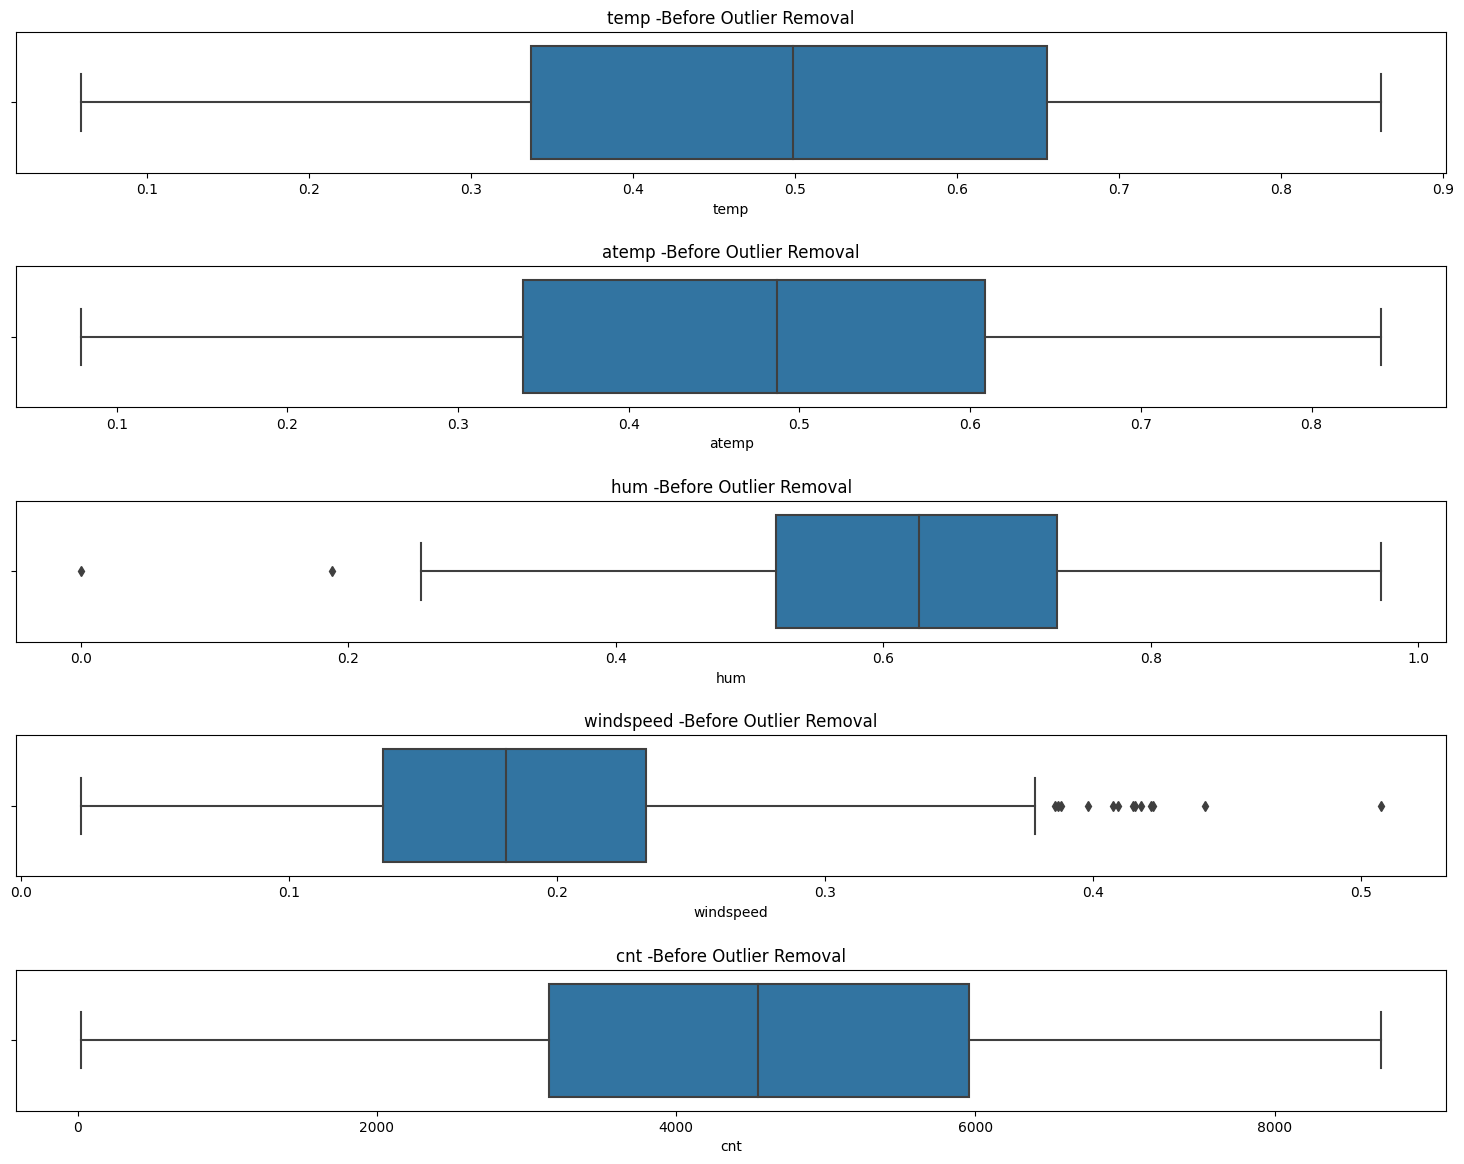

In [285]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data[col])
    plt.title(f"{col} -Before Outlier Removal")
    plt.tight_layout(pad=2)
data.shape

In [286]:
num_cols = ["temp", "atemp", "hum", "windspeed"]

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]

data.shape


(717, 11)

/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


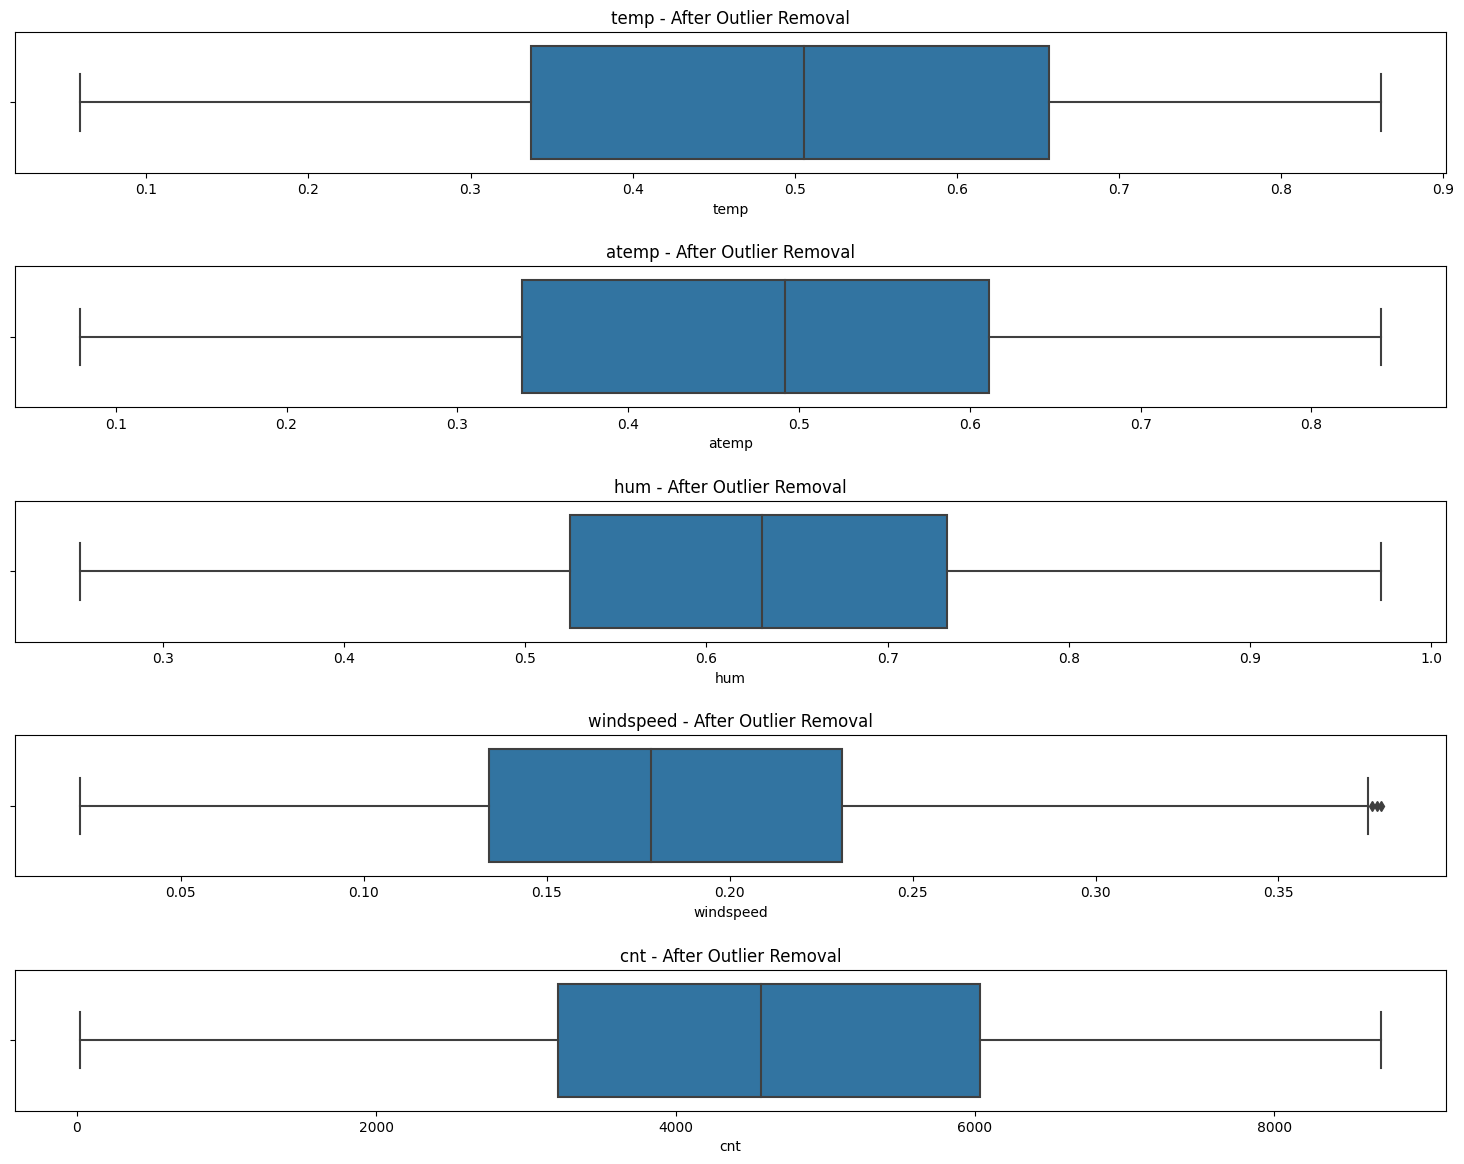

In [287]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)


**removing outliers for hour.csv**

/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


(17379, 12)

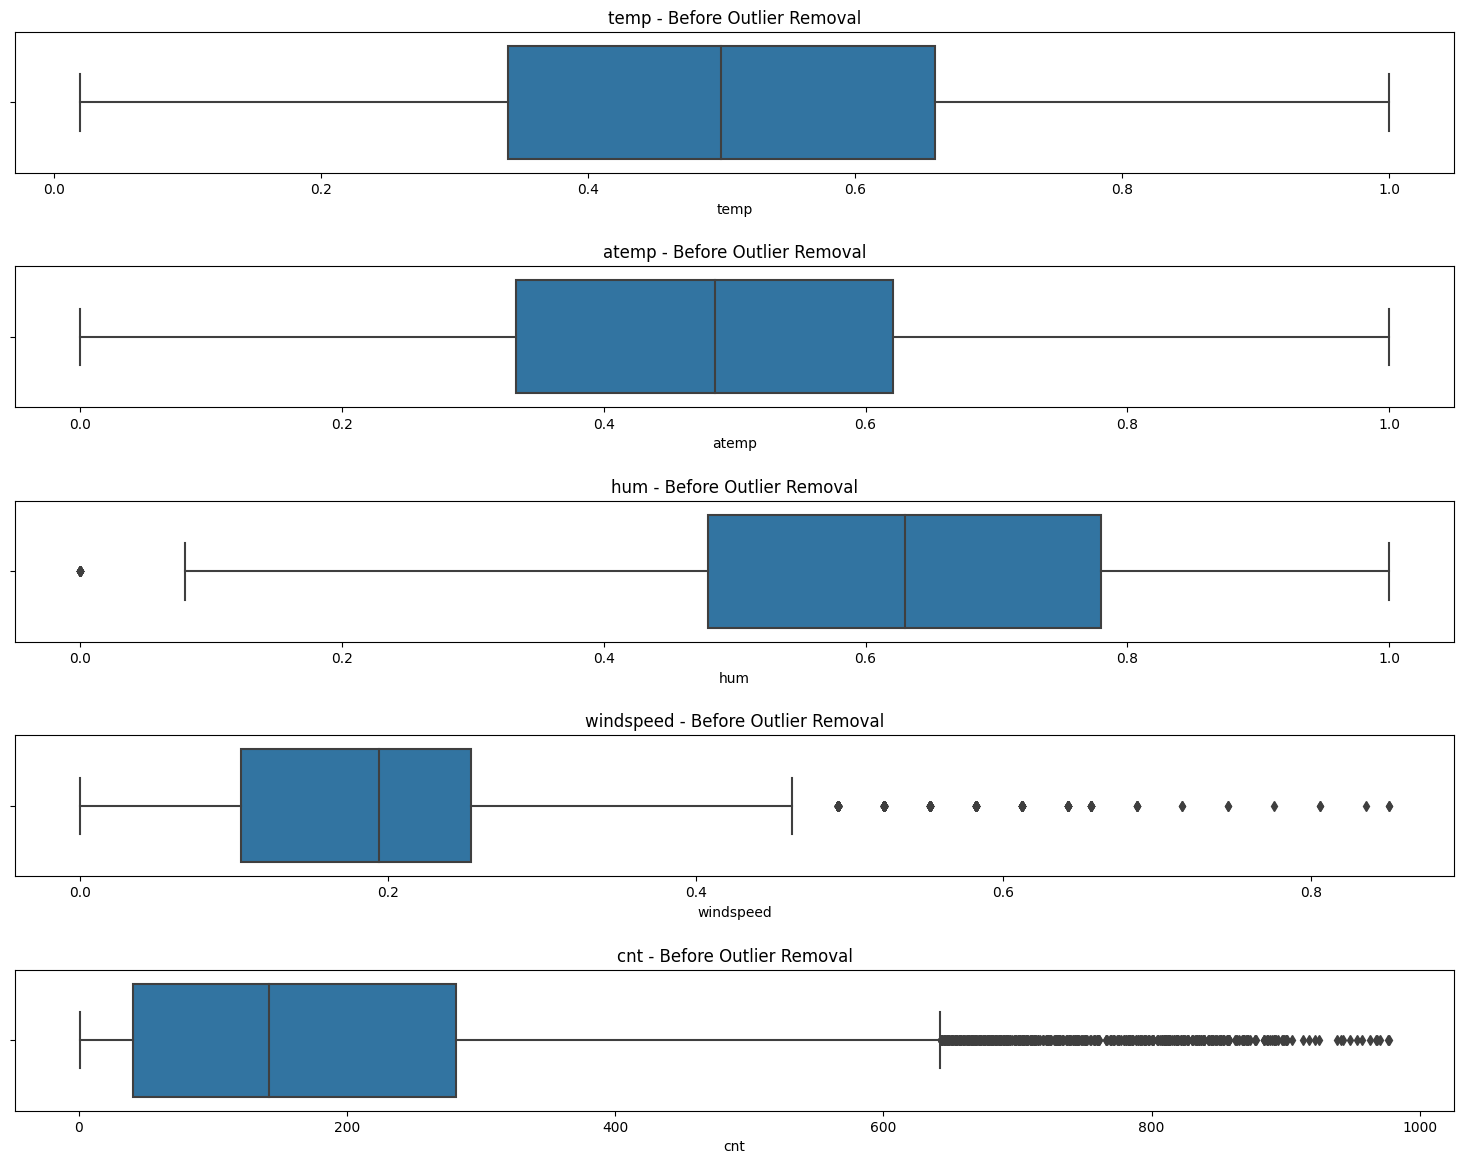

In [288]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data2[col])
    plt.title(f"{col} - Before Outlier Removal")
    plt.tight_layout(pad=2)
data2.shape

In [289]:
num_cols = data2.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    Q1 = data2[col].quantile(0.25)
    Q3 = data2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data2[(data[col] >= lower) & (data2[col] <= upper)]

data2.shape


(17379, 12)

/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


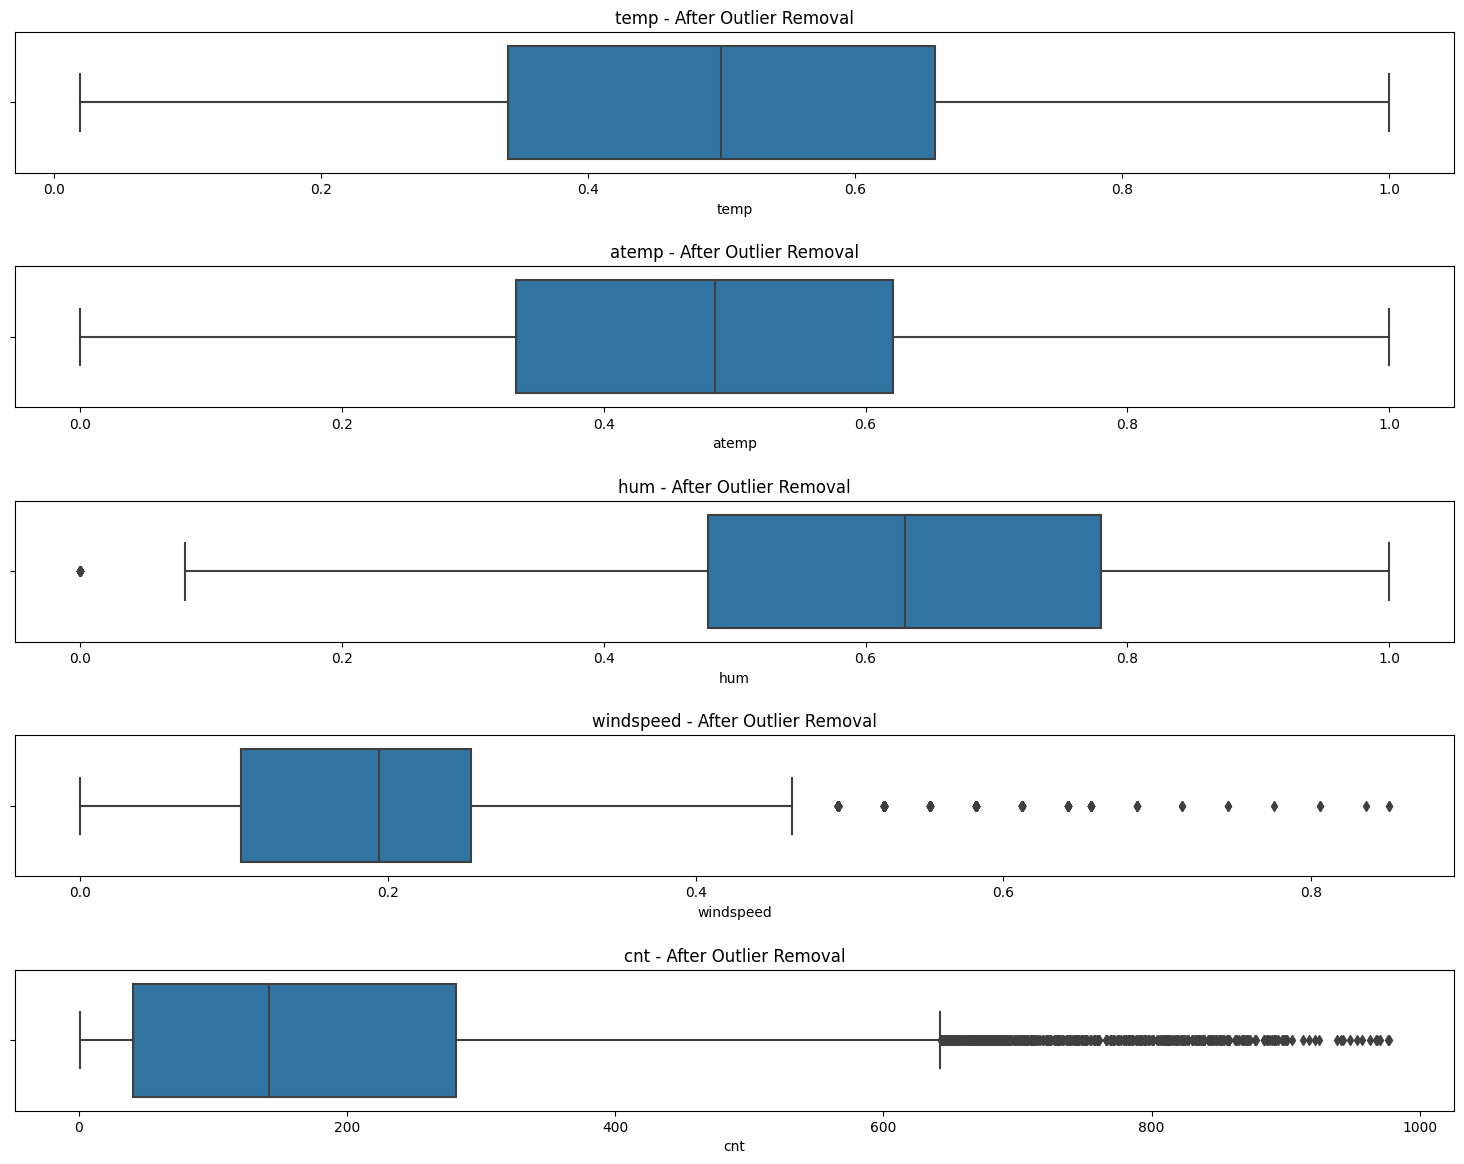

In [290]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data2[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)


In [291]:
X_day = data.drop("cnt", axis=1)
y_day = data["cnt"]

X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42
)

model_day = RandomForestRegressor()
model_day.fit(X_day_train, y_day_train)

pred_day = model_day.predict(X_day_test)

print("MODEL 1 (Day Data)")
print("MAE:", mean_absolute_error(y_day_test, pred_day))
print("R2:", r2_score(y_day_test, pred_day))

MODEL 1 (Day Data)
MAE: 10.90810218978102
R2: 0.8842897475497631


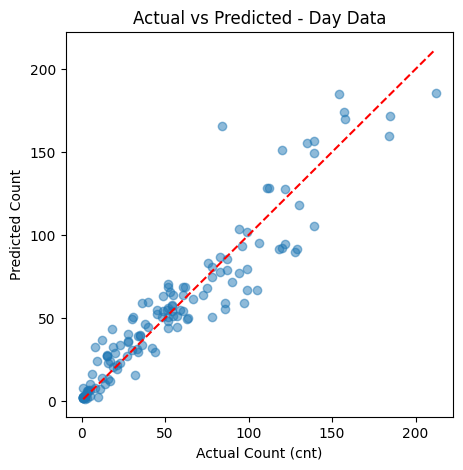

In [292]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_day_test, pred_day, alpha=0.5)
plt.xlabel("Actual Count (cnt)")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - Day Data")
plt.plot([y_day_test.min(), y_day_test.max()],
         [y_day_test.min(), y_day_test.max()],
         'r--')
plt.show()


In [293]:
X_hour = data2.drop("cnt", axis=1)
y_hour = data2["cnt"]

X_hour_train, X_hour_test, y_hour_train, y_hour_test = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42
)

model_hour = RandomForestRegressor()
model_hour.fit(X_hour_train, y_hour_train)

pred_hour = model_hour.predict(X_hour_test)

print("MODEL 2 (Hour Data)")
print("MAE:", mean_absolute_error(y_hour_test, pred_hour))
print("R2:", r2_score(y_hour_test, pred_hour))

MODEL 2 (Hour Data)
MAE: 42.43666268699655
R2: 0.8639829391235011


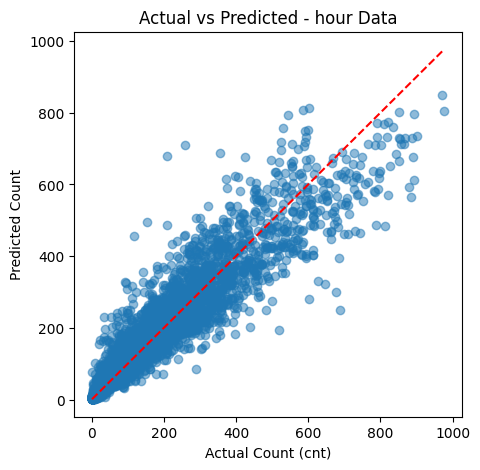

In [294]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_hour_test, pred_hour, alpha=0.5)
plt.xlabel("Actual Count (cnt)")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - hour Data")
plt.plot([y_hour_test.min(), y_hour_test.max()],
         [y_hour_test.min(), y_hour_test.max()],
         'r--')
plt.show()


HYPERPARAMETER TUNING

In [295]:
param_grid_day = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_day = RandomForestRegressor(random_state=42)

grid_day = GridSearchCV(
    estimator=rf_day,
    param_grid=param_grid_day,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_day.fit(X_day_train, y_day_train)

best_day_model = grid_day.best_estimator_
pred_day_tuned = best_day_model.predict(X_day_test)

print("DAY DATASET (After Hyperparameter Tuning)")
print("MAE :", mean_absolute_error(y_day_test, pred_day_tuned))
print("R²  :", r2_score(y_day_test, pred_day_tuned))


DAY DATASET (After Hyperparameter Tuning)
MAE : 19.03308667094271
R²  : 0.7049517835118202


In [296]:
param_grid_hour = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt']
}

rf_hour = RandomForestRegressor(random_state=42)

grid_hour = GridSearchCV(
    estimator=rf_hour,
    param_grid=param_grid_hour,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_hour.fit(X_hour_train, y_hour_train)

best_hour_model = grid_hour.best_estimator_
pred_hour_tuned = best_hour_model.predict(X_hour_test)

print("\nHOUR DATASET (After Hyperparameter Tuning)")
print("MAE :", mean_absolute_error(y_hour_test, pred_hour_tuned))
print("R²  :", r2_score(y_hour_test, pred_hour_tuned))



HOUR DATASET (After Hyperparameter Tuning)
MAE : 48.489415344008954
R²  : 0.8302909886189874


In [297]:
r2_train_day = best_day_model.score(X_day_train, y_day_train)
r2_test_day = r2_score(y_day_test, pred_day_tuned)
overfit_gap_day = abs(r2_train_day - r2_test_day)
lambda_penalty = 0.5
final_score_day = r2_test_day - lambda_penalty * overfit_gap_day

print("DAY DATASET")
print("R2 Train:", r2_train_day)
print("R2 Test :", r2_test_day)
print("Overfit Gap:", overfit_gap_day)
print("Final Score:", final_score_day)

DAY DATASET
R2 Train: 0.8983505946348337
R2 Test : 0.7049517835118202
Overfit Gap: 0.1933988111230135
Final Score: 0.6082523779503135


USING DECISION TREE FOR DAY DATSET 

In [298]:
from sklearn.tree import DecisionTreeRegressor

dt_day = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

dt_day.fit(X_day_train, y_day_train)

pred_dt = dt_day.predict(X_day_test)

r2_train = dt_day.score(X_day_train, y_day_train)
r2_test = r2_score(y_day_test, pred_dt)
gap = abs(r2_train - r2_test)
final = r2_test - 0.5 * gap

print("DECISION TREE - DAY DATASET")
print("R2 Train:", r2_train)
print("R2 Test :", r2_test)
print("Overfit Gap:", gap)
print("Final Score:", final)


DECISION TREE - DAY DATASET
R2 Train: 0.757297138870481
R2 Test : 0.7975523479615563
Overfit Gap: 0.04025520909107527
Final Score: 0.7774247434160186


In [299]:
r2_train_hour = best_hour_model.score(X_hour_train, y_hour_train)
r2_test_hour = r2_score(y_hour_test, pred_hour_tuned)
overfit_gap_hour = abs(r2_train_hour - r2_test_hour)
final_score_hour = r2_test_hour - lambda_penalty * overfit_gap_hour

print("\nHOUR DATASET")
print("R2 Train:", r2_train_hour)
print("R2 Test :", r2_test_hour)
print("Overfit Gap:", overfit_gap_hour)
print("Final Score:", final_score_hour)


HOUR DATASET
R2 Train: 0.9070763831272703
R2 Test : 0.8302909886189874
Overfit Gap: 0.07678539450828292
Final Score: 0.791898291364846


In [306]:
def hourly_forecast_table(model, last_row, start_hour, steps=24):
    results = []
    current_input = last_row.copy()

    for _ in range(steps):
        pred = model.predict(pd.DataFrame([current_input]))[0]
        results.append([start_hour, round(pred, 2)])
        current_input['hr'] = (current_input['hr'] + 1) % 24
        start_hour = (start_hour + 1) % 24

    df = pd.DataFrame(results, columns=["Time", "Predicted cnt"])
    df["Time"] = df["Time"].apply(
        lambda x: f"{x%12 if x%12!=0 else 12} {'AM' if x<12 else 'PM'}"
    )
    return df

last_hour_row = X_hour.iloc[-1]
hourly_output = hourly_forecast_table(
    best_hour_model,
    last_hour_row,
    start_hour=10,
    steps=6
)

hourly_output


,Time,Predicted cnt
0,10 AM,53.05
1,11 AM,18.09
2,12 PM,13.62
3,1 PM,10.29
4,2 PM,9.36
5,3 PM,9.48


In [308]:
import pandas as pd

def daily_forecast_all_days(model, last_row, start_day, steps=7):
    results = []
    current_input = last_row.copy()
    current_day = start_day

    day_map = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    for _ in range(steps):
        pred = model.predict(pd.DataFrame([current_input]))[0]
        results.append([day_map[current_day], round(pred, 2)])
        current_input['weekday'] = (current_input['weekday'] + 1) % 7
        current_day = (current_day + 1) % 7

    df = pd.DataFrame(results, columns=["Day", "Predicted cnt"])
    return df
last_day_row = X_day.iloc[-1]

daily_forecast_output = daily_forecast_all_days(
    dt_day,
    last_day_row,
    start_day=0,  
    steps=7
)

daily_forecast_output


,Day,Predicted cnt
0,Mon,60.31
1,Tue,60.31
2,Wed,60.31
3,Thu,60.31
4,Fri,60.31
5,Sat,60.31
6,Sun,60.31
